trying out the Lopez-Molina case study with the CFRI methodology. Gonna add Marcello's thing with the availability vs cost distribution too

In [1]:
from sys import executable
from pyomo.environ import *
from pyomo.core import *
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from ppopt.mpmodel import MPModeler
from ppopt.mp_solvers.solve_mpqp import solve_mpqp, mpqp_algorithm

Range of allowable design variable values

In [2]:
design_min = [0, 0, 0, 0] # truck capacity 0, 1, 2, 3
design_max = [576, 576, 576, 576] # truck capacity 0, 1, 2, 3. max is 24 trucks with 24 tons capacity each making 1 trip per day

num_design_scenarios = 1
design_scenario_names = list(map(str, range(num_design_scenarios))) # make X scenarios
design_dict = [[np.random.uniform(design_min[0],design_max[0]), np.random.uniform(design_min[1],design_max[1]), np.random.uniform(design_min[2],design_max[2]), np.random.uniform(design_min[3], design_max[3])] for i in range(num_design_scenarios)] # make the dataset assuming a random normal distribution for the designs

Failure modes

In [3]:
site0_dict = {1: 0.8,
              0.5: 0.15,
              0: 0.05}

site1_dict = {1: 0.7,
                0.5: 0.2,
                0: 0.1}

site2_dict = {1: 0.6,
                0.5: 0.25,
                0: 0.15}

site3_dict = {1: 0.9,
                0.5: 0.05,
                0: 0.05}

import itertools
scenarios = list(itertools.product(site0_dict.keys(), site1_dict.keys(), site2_dict.keys(), site3_dict.keys()))
scenario_probabilities = [site0_dict[site0]*site1_dict[site1]*site2_dict[site2]*site3_dict[site3] for site0, site1, site2, site3 in scenarios]


Stochastic flexibility for one realization with supply AND availability uncertainties

In [6]:
# take all the pkl pull data and put it into a dataframe
import os

directory = 'pkl_pull'

cfri_df = pd.DataFrame()
for filename in os.listdir(directory):
    if filename.endswith(".pkl"):
        cfri_df = pd.concat([cfri_df, pd.read_pickle(os.path.join(directory, filename))])


In [7]:
design_sf_new = cfri_df.copy()

# normalize the d coefficients by 576
design_sf_new['d0'] = design_sf_new['d0']/576
design_sf_new['d1'] = design_sf_new['d1']/576
design_sf_new['d2'] = design_sf_new['d2']/576
design_sf_new['d3'] = design_sf_new['d3']/576

# drop the 0 values
design_sf_new = design_sf_new[design_sf_new['cfri'] != 0]

X = design_sf_new.drop('cfri', axis = 1)
y = design_sf_new['cfri']

In [8]:
# train/test split
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model


might need to try a neural net for this instead

0.7771038919028916


Text(0, 0.5, 'Predicted')

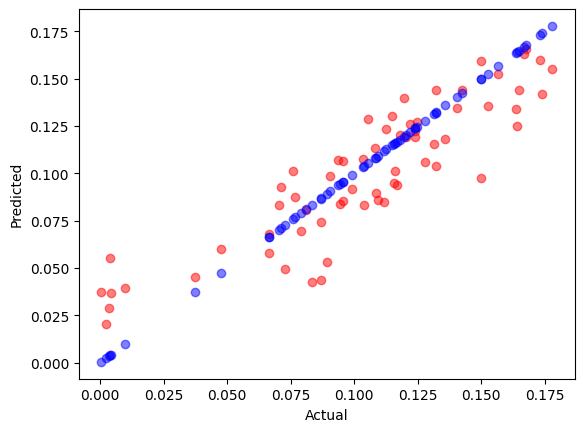

In [116]:
poly = PolynomialFeatures(degree=2)

poly_variables = poly.fit_transform(X)
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(poly_variables, y, test_size=0.3)

model = linear_model.LinearRegression()

model.fit(X_poly_train, y_poly_train)
y_poly_pred = model.predict(X_poly_test)
print(r2_score(y_poly_test, y_poly_pred))
plt.figure
plt.scatter(y_poly_test, y_poly_pred, alpha=0.5, color = 'red')
plt.scatter(y_poly_test, y_poly_test, alpha=0.5, color = 'blue')
plt.xlabel('Actual')
plt.ylabel('Predicted')

In [117]:
coefs = model.coef_
intercept = model.intercept_

In [118]:
coefs

array([ 0.        ,  0.32458476,  0.12353231,  0.33618605,  0.59486195,
       -0.22908086, -0.00854181,  0.12278125, -0.05145766, -0.15465846,
        0.09749457,  0.12376088, -0.31904074,  0.02268425, -0.4157708 ])

In [3]:
coefs = np.array([ 0.        ,  0.32458476,  0.12353231,  0.33618605,  0.59486195,
       -0.22908086, -0.00854181,  0.12278125, -0.05145766, -0.15465846,
        0.09749457,  0.12376088, -0.31904074,  0.02268425, -0.4157708 ])

In [4]:
intercept = -0.41817538870632415

In [120]:
print(poly.get_feature_names_out())

['1' 'd0' 'd1' 'd2' 'd3' 'd0^2' 'd0 d1' 'd0 d2' 'd0 d3' 'd1^2' 'd1 d2'
 'd1 d3' 'd2^2' 'd2 d3' 'd3^2']


Now for the design optimization bits

In [26]:
m = ConcreteModel()

suppliers = ['A', 'B', 'C']
markets = ['D', 'E', 'F']
sites = ['0', '1', '2', '3']

supply_theta = {'A': 45000, 'B': 100000, 'C': 75000}

conv = 1/2.4 # basis is feed

demand = {'D': 0, 'E': 60000, 'F': 25000} # demand of product

no_trips = 365 # number of trips made by each truck per year, basically one round trip per day per truck

site_cap = {'0': 50000, '1': 50000, '2': 50000, '3': 75000} # capacity of each site, basis is feed

flex_goal = 0.17 # goal for cfri

m.suppliers = Set(initialize=suppliers)
m.markets = Set(initialize=markets)
m.sites = Set(initialize=sites)

# control variables
m.product = Var(m.sites, domain = NonNegativeReals, doc = 'amount of product made at each site')
m.feed = Var(m.sites, domain = NonNegativeReals, doc = 'amount of feed used at each site')
m.feed_ship = Var(m.suppliers, m.sites, domain = NonNegativeReals, doc = 'amount of feed shipped from supplier to site')
m.product_ship = Var(m.sites, m.markets, domain = NonNegativeReals, doc = 'amount of product shipped from site to market')

# design variables
m.trans_cap = Var(m.sites, domain = NonNegativeReals, doc = 'transport capacity around each site')
m.capex = Var(domain = NonNegativeReals)

# CFRI
m.cfri = Var(domain = NonNegativeReals)

# constraints
def balance_feed(model, site):
    return model.feed[site] == sum(model.feed_ship[supplier, site] for supplier in model.suppliers)
m.balance_feed_con = Constraint(m.sites, rule=balance_feed)

def limit_feed(model, supplier):
    return sum(model.feed_ship[supplier, site] for site in model.sites) - supply_theta[supplier] <= 0
m.limit_feed_con = Constraint(m.suppliers, rule=limit_feed)

def conversion(model, site):
    return model.product[site] == model.feed[site]*conv
m.conversion_con = Constraint(m.sites, rule=conversion)

def limit_production(model, site):
    return model.feed[site] - site_cap[site] <=0
m.limit_production_con = Constraint(m.sites, rule=limit_production)

def balance_product(model, site):
    return model.product[site] == sum(model.product_ship[site, market] for market in model.markets)
m.balance_product_con = Constraint(m.sites, rule=balance_product)

def limit_demand(model, market):
    return sum(model.product_ship[site, market] for site in model.sites) >= demand[market]
m.limit_demand_con = Constraint(m.markets, rule=limit_demand)

def limit_transport(model, site):
    return sum(model.feed_ship[supplier, site] for supplier in model.suppliers) + sum(model.product_ship[site, market] for market in markets) - model.trans_cap[site] * no_trips <= 0
m.limit_transport_con = Constraint(m.sites, rule=limit_transport)

def transport_cost(model):
    return model.capex == sum(model.trans_cap[site] for site in model.sites)
m.transport_cost_con = Constraint(rule=transport_cost)

def cfri_rule(model):
    d0_ratio = model.trans_cap[sites[0]]/576
    d1_ratio = model.trans_cap[sites[1]]/576
    d2_ratio = model.trans_cap[sites[2]]/576
    d3_ratio = model.trans_cap[sites[3]]/576

    return coefs[0] + coefs[1]*d0_ratio + coefs[2]*d1_ratio + coefs[3]*d2_ratio + coefs[4]*d3_ratio + coefs[5]*d0_ratio**2 + coefs[6]*d0_ratio*d1_ratio + coefs[7]*d0_ratio*d2_ratio + coefs[8]*d0_ratio*d3_ratio + coefs[9]*d1_ratio**2 + coefs[10]*d1_ratio*d2_ratio + coefs[11]*d1_ratio*d3_ratio + coefs[12]*d2_ratio**2 + coefs[13]*d2_ratio*d3_ratio + coefs[14]*d3_ratio**2 + intercept == model.cfri 
m.cfri_con = Constraint(rule=cfri_rule)

def flex_rule(model):
    return model.cfri >= flex_goal
m.flex_con = Constraint(rule=flex_rule)

# objective
m.obj = Objective(expr = (m.capex), sense=minimize)

# solve
results = SolverFactory('gurobi', solver_io = 'python').solve(m, tee = True)

Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 28 rows, 38 columns and 102 nonzeros
Model fingerprint: 0x33e1191f
Model has 1 quadratic constraint
Coefficient statistics:
  Matrix range     [4e-01, 4e+02]
  QMatrix range    [3e-08, 1e-06]
  QLMatrix range   [2e-04, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e-01, 1e+05]
  QRHS range       [4e-01, 4e-01]
Presolve removed 11 rows and 5 columns

Continuous model is non-convex -- solving as a MIP

Presolve removed 11 rows and 9 columns
Presolve time: 0.00s
Presolved: 54 rows, 40 columns, 149 nonzeros
Presolved model has 10 bilinear constraint(s)
         in product terms.
         Presolve was not able to compute smaller bounds for these variables.
         Consider boundin

In [27]:
m.cfri.value

0.16999993576929245

In [28]:
value(m.obj)

1947.6728846734568

In [29]:
m.trans_cap.pprint()

trans_cap : transport capacity around each site
    Size=4, Index=sites
    Key : Lower : Value              : Upper : Fixed : Stale : Domain
      0 :     0 : 460.80507887371914 :  None : False : False : NonNegativeReals
      1 :     0 :  536.6485791647319 :  None : False : False : NonNegativeReals
      2 :     0 : 481.12445944190455 :  None : False : False : NonNegativeReals
      3 :     0 : 469.09476719310106 :  None : False : False : NonNegativeReals


Text(0.5, 1.0, 'CFARI vs Investment Cost [$], supply chain')

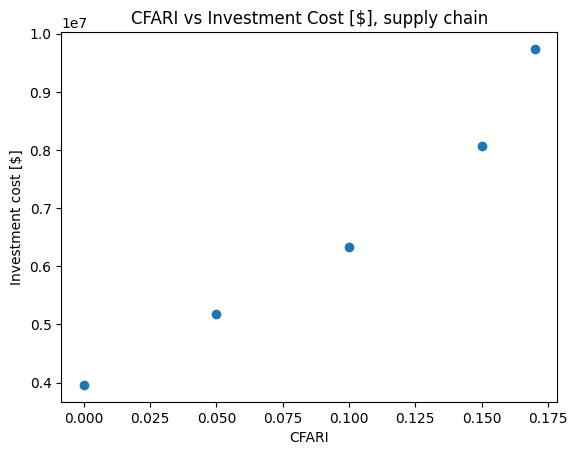

In [31]:
cfri = [0,0.05,0.1,0.15,0.17]
capex = [791.7808219178082,1035.8505517201183,1267.4738792347662,1614.1445336464928,1947.6728846734568]
capex_factor = [i * 5000 for i in capex]

plt.scatter(cfri, capex_factor)
plt.xlabel('CFARI')
plt.ylabel('Investment cost [$]')
plt.title('CFARI vs Investment Cost [$], supply chain')